##     Case study iMM904 curation
 Using the iMM904 model as a case study, we have used Thermo-Flux and did the few manual curation steps to show how models can be converted into a combined thermodynamic-stoichiometric model.
Here, we present the steps that required manual attention when following the protocol described in the publication. "
    

In this notebook, we generate the 3 last subplots from figure 7 (B-D).

In [1]:
import cobra
from cobra import Model, Reaction, Metabolite
import sys
import os 

sys.path.append(f'{os.getcwd()}/../../')
from thermo_flux.core.metabolite import ThermoMetabolite
import thermo_flux
from thermo_flux.io import load_excel as ex
from thermo_flux.core.model import ThermoModel, ThermoReaction
from equilibrator_api import  Q_
import pandas as pd
from thermo_flux.io import load_gams as gs
from thermo_flux.io import helper_load as hl
from thermo_flux.utils.vis import compare_met
import numpy as np
import gurobipy as  gp
from gurobipy import GRB


import seaborn as sns
import matplotlib.pyplot as plt


In [57]:
PLOTTING_DATA_FOLDER='data_forplotting/'

Import sbml model from BiGG

In [2]:
from cobra.io import load_json_model
model=load_json_model('iMM904.json')

#set objective to biomass
model.objective = model.reactions.BIOMASS_SC5_notrace
model.reactions.EX_co2_e.id='co2_EX'
model.reactions.EX_o2_e.id='o2_EX'
model.reactions.EX_etoh_e.id='etoh_EX'
model.repair()

for rxn in model.reactions:
    if 'EX_' not in rxn.id:
        rxn.lower_bound=-500 if rxn.lower_bound==-999999.0 else rxn.lower_bound
        rxn.upper_bound=500 if rxn.upper_bound==999999.0 else rxn.upper_bound
    else:
        rxn.lower_bound=-500 if rxn.lower_bound==-999999.0 else rxn.lower_bound
        rxn.upper_bound=500 if rxn.upper_bound==999999.0 else rxn.upper_bound
       # print(rxn.id,rxn.lower_bound,rxn.upper_bound)

#reset O2 exchange bound
model.optimize().to_frame().loc['BIOMASS_SC5_notrace']['fluxes']
model.reactions.o2_EX.bounds=(-500,0)

print(model.optimize().to_frame().loc['BIOMASS_SC5_notrace']['fluxes'])
model.optimize().to_frame().loc[[rxn.id for rxn in model.boundary]]



Set parameter Username
Set parameter LicenseID to value 2749904
Academic license - for non-commercial use only - expires 2026-12-04
0.9748814206733485


,fluxes,reduced_costs
EX_epistest_SC_e,0.0,-96.275549
EX_epist_e,0.0,-1.676719
EX_ergst_e,0.0,-1.722387
EX_ergstest_SC_e,0.0,-96.321217
EX_13BDglcn_e,0.0,-0.196130
...,...,...
EX_xyl__D_e,0.0,-0.163442
EX_xylt_e,0.0,-0.176421
EX_rib__D_e,0.0,-0.163442
EX_zymst_e,0.0,-1.620476


Solver status is 'infeasible'.


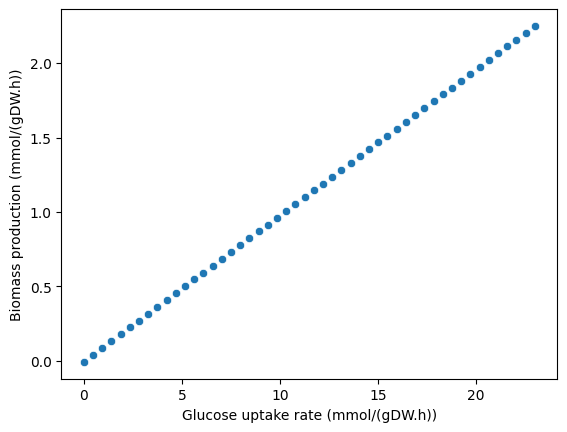

In [3]:
#plot biomass yield for stoichiometric model
#GUR_range=[-0.25, -0.57, -0.6 , -1.1 , -1.67, -2.14, -2.22, -2.83, -3.24, -3.7, -4.67, -5.44, -7.62, -8.09, -8.33, -10.23, -13.18, -15.7, -22.42]
GUR_range = np.linspace(-0, -23, 50)

GUR_plot_range=[-x for x in GUR_range]
biomass_flux=[]
etoh_flux=[]
o2_flux=[]
co2_flux=[]
for GUR in GUR_range:
    model.reactions.EX_glc__D_e.upper_bound=0
    model.reactions.EX_glc__D_e.lower_bound=GUR
    sol = model.optimize()
    #add values to list
    biomass_flux.append(sol.fluxes.loc['BIOMASS_SC5_notrace'])
    etoh_flux.append(sol.fluxes.loc['etoh_EX'])
    o2_flux.append(sol.fluxes.loc['o2_EX'])
    co2_flux.append(sol.fluxes.loc['co2_EX'])
#plot biomass vs GUR in a scatter plot
sns.scatterplot(x=GUR_plot_range,y=biomass_flux)
plt.xlabel('Glucose uptake rate (mmol/(gDW.h))')
plt.ylabel('Biomass production (mmol/(gDW.h))')
fba_flux=pd.DataFrame({'biomass_EX':biomass_flux,'etoh_EX':etoh_flux,'o2_EX':o2_flux,'co2_EX':co2_flux},index=GUR_range)
# plt.savefig('Figures/growth_stoichio_only.png',dpi=300)
# model.optimize().to_frame().loc['BIOMASS_SC5_notrace']/model.optimize().to_frame().loc['EX_glc__D_e']

### Step 1 - Physical and Biochemical parameters

In [4]:
tmodel=ThermoModel(model,split_biomass=True, add_charge_exchange= True)

Initializing component contribution object...
cxcalc is not installed, operating in read-only mode. A local cache may be loaded, but no compounds can be created. Install cxcalc and obtain a ChemAxon license to enable compound creation.
Loading compounds from iMM904_compound.sqlite
added reaction:  biomass_ce: biomass_c <=> biomass_e
added reaction:  biomass_EX: biomass_e <=> 
added reaction:  charge_ce: charge_e <=> charge_c
added reaction:  EX_charge: charge_e <=> 
added reaction:  charge_cm: charge_m <=> charge_c
added reaction:  charge_cx: charge_x <=> charge_c
added reaction:  charge_cr: charge_r <=> charge_c
added reaction:  charge_cv: charge_v <=> charge_c
added reaction:  charge_cg: charge_g <=> charge_c
added reaction:  charge_cn: charge_n <=> charge_c


In [5]:
#define the biochemical parameters of the model

tmodel.phi={'ec': Q_(-0.06,'volt'), 'cm': Q_(-0.16,'volt'),'cx':Q_(0,'volt'),'cr':Q_(0,'volt'),'cv':Q_(0,'volt'),'cg':Q_(0,'volt'),'cn':Q_(0,'volt')}
tmodel.pH={'c':Q_(7),'e':Q_(5),'m':Q_(7.4),'r':Q_(7),'v':Q_(5.5),'g':Q_(7),'x':Q_(7),'n':Q_(7)} #On the intracellular pH of baker’s yeast(r), Martinez-Munoz et al. 2008(v), Juan Llopis et al 1998 (g), 7 is default pH

##from first version
# tmodel.pH={'c':Q_(7.2),'e':Q_(5),'m':Q_(7.4),'r':Q_(7.4),'v':Q_(7.4),'g':Q_(7.4),'x':Q_(7.4),'n':Q_(7.4)}
# tmodel.phi={'ec': Q_(-0.06,'volt'), 'cm': Q_(-0.16,'volt'),'cx':Q_(-0.16,'volt'),'cr':Q_(-0.16,'volt'),'cv':Q_(-0.16,'volt'),'cg':Q_(-0.16,'volt'),'cn':Q_(-0.16,'volt')}
#assuming same membrane potential between cytosol and organelles than c and mitochondria ?

#change max drGcalc_drGt
tmodel._max_drG=Q_(1e6,'kJ/mol') #max is already 1e8 shouldnt need to change


### Step 2 - Definition of metabolites

In [6]:
tmodel.get_compounds(search = True)

[████████████████████████████████████████] 1236/1236 charge_n                  



[<ThermoMetabolite biomass_c at 0x797e54399630>,
 <ThermoMetabolite biomass_e at 0x797e543990c0>]

In [7]:
#define biomass parameters 
#if the biomass formula is not automatically calcualted it's important to specifiy the hydrogen atoms in biomass to ensure correct proton balancing 
tmodel.metabolites.biomass_c.formula = 'H67'
tmodel.metabolites.biomass_e.formula = 'H67'

#manually define charge of cytochrome C so electron movement is correctly calcualted
tmodel.metabolites.focytc_m.charge = 2
tmodel.metabolites.focytc_m.redox= True #define as redox metabolite 
tmodel.metabolites.ficytc_m.charge = 3
tmodel.metabolites.ficytc_m.redox = True

### Step 3 - metabolites formation energies

When specifying the value of `dfGprime` for the biomass metabolite, we should plug in the values in units of **J/gDW**. This differs from all the other reactions in the model, for which values of **kJ/mol** are used.

The reason for this discrepancy has to do with the units of the fluxes.

For a normal reaction:
$g_{diss, rxn} = \Delta_rG \times v = (kJ/mol) \times (mmol/gDW/h) = (10^3 J/mol) \times (10^{-3} mol/gDW/h) = J/gDW/h$

For the biomass reaction:
$g_{diss, bio} = \Delta_fG_{bio} \times \mu = (J/gDW) \times (gDW/gDW/h) = J/gDW/h $

Since thermoflux handles all reactions the same when determining the gibbs energy dissipation rate (multiplying $v$ by $\Delta_rG$), we have to **pretend** that the biomass formation energy has units of kJ/mol. E.g:
`tmodel.metabolites.biomass_c.dfGprime = Q_(701.767, "kJ/mol")` (where 701.767 is the formation energy of E.coli biomass at cytosolic pH, in units of J/gDW)

In [8]:
#define biomass properties
tmodel.reactions.BIOMASS_SC5_notrace.id='biomass_c' #update biomass reaction name for convenience

tmodel.metabolites.biomass_c.dfG0 = Q_(-3.04,'kJ/mol')*1000 #From Battley 1991, *1000 for mmol flux units (actual units here are J/gDW)
tmodel.metabolites.biomass_e.dfG0 = Q_(-3.04,'kJ/mol')*1000


### Step 4 - Transporters

In [9]:
#idenfity transporters where the transported metabolite is empty
#these could either be redox reactions or proton pumps just moving electrons (charge) and protons 
#or they could be transporters with chemcial transformation during the transport process
for reaction in tmodel.reactions:
    if len(reaction.compartments) > 1:
        if thermo_flux.tools.drg_tools.calc_transported_mets(reaction) == {}:
            print(reaction.id, reaction, thermo_flux.tools.drg_tools.calc_transported_mets(reaction))


ASPOcm ASPOcm: asp__L_c + fad_m --> fadh2_m + h_c + iasp_c {}
ATPS ATPS: atp_c + h2o_c --> adp_c + h_e + pi_c {}
DHORD4i DHORD4i: dhor__S_c + q6_m --> orot_c + q6h2_m {}
DOLPMTcer DOLPMTcer: dolp_c + gdpmann_c --> dolmanp_r + gdp_c {}
DXHPScm DXHPScm: h2o_c + q6_m + spmd_c --> 13dampp_c + 4abutn_c + q6h2_m {}
D_LACDcm D_LACDcm: 2.0 ficytc_m + lac__D_c --> 2.0 focytc_m + pyr_c {}
FDNG FDNG: for_c + h_c + q6_m --> co2_c + q6h2_m {}
FRDcm FRDcm: fadh2_m + fum_c --> fad_m + succ_c {}
L_LACD2cm L_LACD2cm: 2.0 ficytc_m + lac__L_c --> 2.0 focytc_m + pyr_c {}
NADH2_u6cm NADH2_u6cm: h_c + nadh_c + q6_m --> nad_c + q6h2_m {}


In [10]:
#DOLPMTcer involved chemcial transformation of dolp. We assume transport of dolmanp for thermodynamic calcualtion
tmodel.reactions.DOLPMTcer.transported_mets = {tmodel.metabolites.dolmanp_r: -1}

In [11]:
## add proton transport reactions ##the directions are constrained by pH gradients

tmodel.add_proton_exchange()

added reaction:  H_cm: h_m <=> h_c
added reaction:  H_cx: h_x <=> h_c
added reaction:  H_cr: h_r <=> h_c
added reaction:  H_cv: h_v <=> h_c
added reaction:  H_cg: h_g <=> h_c
added reaction:  H_cn: h_n <=> h_c


In [12]:
## add transporter variants for all phosphate transporters

for rxn in [r for r in tmodel.reactions if len(r.compartments) > 1 and any(m.id.split('_')[0] == 'pi' for m in r.metabolites)
            and not any(m.id.split('_')[0] == 'atp' for m in r.metabolites )]:
    new_reactions = thermo_flux.tools.drg_tools.add_transporter_varaints(rxn,balance_charge=True,add_charge_neutral = True, round_dp=2)
    if new_reactions is not None:
        if len(new_reactions) > 0:
            for new_reaction in new_reactions:
                print(new_reaction)

PIt2m0: 1.83 h_c + pi_c <=> 2.0 h_m + pi_m


to remove

In [13]:
tmodel.reactions.ATPS

Reaction identifier,ATPS
Name,ATPase cytosolic
Memory address,0x797e5772c370
Stoichiometry,atp_c + h2o_c --> adp_c + h_e + pi_c ATP C10H12N5O13P3 + H2O H2O --> ADP C10H12N5O10P2 + H+ + Phosphate
GPR,(YCR024C_A and YEL017C_A and YGL008C) or (YCR024C_A and YEL017C_A and YPL036W)
Lower bound,0.0
Upper bound,500


### Step 5 - charge and proton balancing

In [14]:
for rxn in tmodel.reactions:
    thermo_flux.tools.drg_tools.reaction_balance(rxn, balance_charge=True, balance_mg=False)

manually curate all reactions that gave a warning

In [15]:
#ATPS3v is vacuolar ATP synthase transporting three protons per ATP
tmodel.reactions.ATPS3v.transported_h = {'v': 3.0, 'c': -3.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.ATPS3v, balance_charge=True, balance_mg=False)


In [16]:
tmodel.reactions.ASPOcm.transported_h= {'m': 2.0, 'c': -2.0}
tmodel.reactions.ASPOcm.transported_charge= {'m': -2.0, 'c': 2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.ASPOcm, balance_charge=True, balance_mg=False)

In [17]:
tmodel.reactions.ATPS.transported_h={'c':-1,'e':1}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.ATPS, balance_charge=True, balance_mg=False)

In [18]:
#DHORD4i
tmodel.reactions.DHORD4i.transported_h = {'m': 2.0, 'c': -2.0}
tmodel.reactions.DHORD4i.transported_charge= {'m': -2.0, 'c': 2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.DHORD4i, balance_charge=True, balance_mg=False)

In [19]:
#DXHPScm is fine

In [20]:
# D_LACDcm
tmodel.reactions.D_LACDcm.transported_charge= {'m': 2.0, 'c': -2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.D_LACDcm, balance_charge=True, balance_mg=False)

In [21]:
##FDNG
tmodel.reactions.FDNG.transported_h = {'m': 2.0, 'c': -2.0}
tmodel.reactions.FDNG.transported_charge= {'m': -2.0, 'c': 2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.FDNG, balance_charge=True, balance_mg=False)

In [22]:
#FRDcm ## opposite then others h transport rxn we did until now
tmodel.reactions.FRDcm.transported_h = {'m': -2.0, 'c': 2.0}
tmodel.reactions.FRDcm.transported_charge= {'m': 2.0, 'c': -2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.FRDcm, balance_charge=True, balance_mg=False)

In [23]:
# L_LACD2cm
tmodel.reactions.L_LACD2cm.transported_charge= {'m': 2.0, 'c': -2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.L_LACD2cm, balance_charge=True, balance_mg=False)
tmodel.reactions.L_LACD2cm

Reaction identifier,L_LACD2cm
Name,L Lactate dehydrogenase cytosolicmitochondrial
Memory address,0x797e55fb03a0
Stoichiometry,2.0 ficytc_m + lac__L_c --> 2.0 focytc_m + 2.0 h_c + pyr_c 2.0 Ferricytochrome c C42H52FeN8O6S2 + L-Lactate --> 2.0 Ferrocytochrome c C42H53FeN8O6S2 + 2.0 H+ + Pyruvate
GPR,(YML054C and YEL039C) or (YML054C and YJR048W)
Lower bound,0.0
Upper bound,500


In [24]:
# NADH2_u6cm
tmodel.reactions.NADH2_u6cm.transported_h = {'m': 2.0, 'c': -2.0}
tmodel.reactions.NADH2_u6cm.transported_charge= {'m': -2.0, 'c': 2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.NADH2_u6cm, balance_charge=True, balance_mg=False)

### Step 6 - Calculation of Gibbs energy of reactions
Add thermodynamic constraints and parameters

In [25]:
#change max flux to 500 for all reactions

tmodel.reactions.get_by_id("biomass_EX").bounds = (0,500)
tmodel.reactions.get_by_id("biomass_c").bounds = (0,500)
tmodel.reactions.get_by_id("biomass_ce").bounds = (0,500)


for rxn in tmodel.reactions:
    rxn.lower_bound = -500 if rxn.lower_bound == -1000 else rxn.lower_bound
    rxn.upper_bound = 500 if rxn.upper_bound == 1000 else rxn.upper_bound
tmodel.objective = tmodel.reactions.biomass_EX

In [26]:
tmodel.update_thermo_info(fit_unknown_dfG0=False,search=True)


Identifying compounds...


[████████████████████████████████████████] 1244/1244 Mg_n                                                       

Estimating dfG0'...


ficytc_m 0 kilojoule / mole
focytc_m 0 kilojoule / mole
biomass_c 0 kilojoule / mole
biomass_e 0 kilojoule / mole
[████████████████████████████████████████] 1244/1244 Mg_n                                                                                                                                                                                                                                                                                                                                                          

Estimating drG0'...


[████████████████████████████████████████] 1594/1594 PIt2m0                                                                                                             



In [27]:
for met in tmodel.metabolites:
    if met.ignore_conc:
        print(met.id,met.ignore_conc)

h2o_c True
h2o_e True
h2o_g True
h2o_m True
h2o_n True
h2o_r True
h2o_v True
h2o_x True
h_c True
h_e True
h_g True
h_m True
h_n True
h_r True
h_v True
h_x True
oh1_c True
oh1_m True
biomass_c True
biomass_e True
charge_c True
charge_e True
charge_m True
charge_x True
charge_r True
charge_v True
charge_g True
charge_n True


In [28]:
#ignore snd for charge ?
for rxn in tmodel.reactions:
    if 'charge' in rxn.id and 'EX' not in rxn.id:#charge reactions are constrained by 2nd law 
        print(rxn.id,rxn.ignore_snd)
        rxn.ignore_snd=True
        print(rxn.id,rxn.ignore_snd)
        


#tmodel.reactions.EX_charge.ignore_snd=True

charge_ce False
charge_ce True
charge_cm False
charge_cm True
charge_cx False
charge_cx True
charge_cr False
charge_cr True
charge_cv False
charge_cv True
charge_cg False
charge_cg True
charge_cn False
charge_cn True


### Step 7 - Establishment of the thermodynamic-stoichiometric solution space
Note : In our curation of the iMM904 model, due to the limited information available for the membrane potential of organelles, we chose to allow the free leakage of ions (charges) across the membrane. 
Allowing free movement of charges between compartments prevents over-constraining the model to potentially incorrect information.
For more detailed analysis of charge transport or models where more information is available on membrane physiology then a constraint on the second law could be added for these charge transport reactions.  

In [29]:
##x r v g n
tmodel.reactions.H_cm.ignore_snd=False
tmodel.reactions.H_cv.ignore_snd=False
tmodel.reactions.H_cx.ignore_snd=False
tmodel.reactions.H_cr.ignore_snd=False
tmodel.reactions.H_cg.ignore_snd=False
tmodel.reactions.H_cn.ignore_snd=False


In [30]:
# add the TFBA variables to the model
tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
tmodel.add_TFBA_variables(gdiss_constraint = False, sigmac_limit = (5000/tmodel.T.m), error_type = 'covariance',qnorm=1,alpha=0.95)
tmodel.m.update()

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10


In [31]:
tmodel.optimize()


,fluxes,reduced_costs
CITtcp,0.000000,-0.000000
13BGH,0.000000,-0.022637
13BGHe,0.000000,0.000000
13GS,3.755118,0.000000
16GS,0.000000,0.000000
...,...,...
H_cr,42.774191,0.000000
H_cv,0.000000,0.000000
H_cg,0.000000,0.000000
H_cn,0.000000,0.000000


In [32]:
thermo_flux.solver.gurobi.model_start(tmodel,'fixed_dir_firstTFBA.sol', ignore_vars=['all'],fix_vars=['qm'],fix='bound')


In [33]:
tmodel.m.params.TimeLimit=10 ## in seconds
tmodel.m.optimize()


Set parameter TimeLimit to value 10
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  10
NonConvex  2

Optimize a model with 14480 rows, 12893 columns and 341179 nonzeros (Max)
Model fingerprint: 0x085d2027
Model has 2 linear objective coefficients
Model has 1 simple general constraint
  1 NORM
Variable types: 11299 continuous, 1594 integer (1594 binary)
Coefficient statistics:
  Matrix range     [6e-06, 1e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-06, 1e+06]
  RHS range        [7e-15, 1e+06]
Presolve removed 9683 rows and 8596 columns
Presolve time: 0.08s
Presolved: 4797 rows, 4297 columns, 14590 nonzeros
Variable types: 3336 continuous, 961 integer (961 binary)

Root relaxation: objective 2.608601e+00, 2913 iterations, 0.06 seconds (0.07 wor

In [34]:
# tmodel.m.write('fixed_dir_firstTFBA.sol')

### Analysis and plots for results figure 

In [35]:
#formating
sns.set_palette('viridis')
OUTPUT_FOLDER='./Figures/'
def scale_rcparams(fig,scalingf=None):
    default_figsize = (5, 5)
    current_figsize = fig.get_size_inches()
    scale_x = current_figsize[0] / default_figsize[0]
    scale_y = current_figsize[1] / default_figsize[1]
    scale = min(scale_x, scale_y) if scalingf is None else scalingf
    
    # Update rcParams with scaled values
    plt.rcParams['axes.linewidth'] = 2.05 * scale
    plt.rcParams['lines.linewidth'] = 1.5 * scale
    plt.rcParams['font.size'] = 12.5# 25 * scale #fixed size of 12.5 for all
    plt.rcParams['xtick.major.size'] = 9.84 * scale
    plt.rcParams['ytick.major.size'] = 9.84 * scale
    plt.rcParams['xtick.minor.size'] = 6.56 * scale
    plt.rcParams['ytick.minor.size'] = 6.56 * scale
    #width
    # 'ytick.minor.width': 1.0
    plt.rcParams['xtick.major.width'] = 2.05 * scale
    plt.rcParams['ytick.major.width'] = 2.05 * scale
    plt.rcParams['xtick.minor.width'] = 1.64 * scale
    plt.rcParams['ytick.minor.width'] = 1.64 * scale
    # plt.rcParams['lines.linewidth'] = 1.5 * scale
    plt.rcParams['legend.fontsize'] = 12.5#5 * scale
    plt.rcParams['xtick.labelsize'] =12.5 #25 * scale
    plt.rcParams['ytick.labelsize'] = 12.5#25 * scale
    plt.rcParams['axes.labelsize'] =12.5# 25 * scale
    
    return plt.rcParams

def rescale_axlim(ax,how='both',nbins=4):
    def rescale_ylim(ax,nbins):
        yticks = ax.get_yticks()
        ax.set_yticks(np.linspace(yticks[0], yticks[-1], nbins))
        return ax
    def rescale_xlim(ax,nbins):
        xticks = ax.get_xticks()
        ax.set_xticks(np.linspace(xticks[0], xticks[-1], nbins))
        return ax
    if how=='both':
        ax=rescale_ylim(rescale_xlim(ax,nbins),nbins)
    elif how=='x':
        ax=rescale_xlim(ax,nbins)
    elif how=='y':
        ax=rescale_ylim(ax,nbins)
    return ax

## a) variability analysis then check the magnitude of ranges for 
- FVA with reversible reactions
- FVA with predefined directions
- TFVA

In [36]:
FVA_fluxes=cobra.flux_analysis.flux_variability_analysis(model, [r for r in model.reactions if r.id in [tr.id for tr in tmodel.reactions]],
                                                         fraction_of_optimum=0)
##explore whole space don't restrict on solutions that are close to the FBA optimum

In [37]:
##first maybe check ranges ?
FVA_fluxes['range']=FVA_fluxes['maximum']-FVA_fluxes['minimum']
# FVA_fluxes['range'].plot(kind='hist')
range_FVA=FVA_fluxes['range']
nlargeFVA=len(range_FVA[range_FVA>200])


In [38]:
##also do it for fully reversible FVA
for r in model.reactions : 
    try:
        r.bounds=-500,500
    except:
        pass
for r in tmodel.reactions : ##also if we have added reactions with thermoflux
    try:
        model.reactions.get_by_id(r.id).bounds=-500,500
    except Exception as e:
        print(e)
        pass

FVA_free_fluxes=cobra.flux_analysis.flux_variability_analysis(model, [r for r in model.reactions if r.id in [tr.id for tr in tmodel.reactions]],
                                                         fraction_of_optimum=0)

'biomass_c'
'biomass_ce'
'biomass_EX'
'charge_ce'
'EX_charge'
'charge_cm'
'charge_cx'
'charge_cr'
'charge_cv'
'charge_cg'
'charge_cn'
'H_cm'
'H_cx'
'H_cr'
'H_cv'
'H_cg'
'H_cn'
'PIt2m0'


In [39]:
FVA_free_fluxes['range']=FVA_free_fluxes['maximum']-FVA_free_fluxes['minimum']


In [40]:
## how much reactions are fully reversible ? 
FBArev_rxn=[]
for r in FVA_fluxes.index:
    if FVA_fluxes.loc[r,'minimum']<0 and FVA_fluxes.loc[r,'maximum']>0:
        FBArev_rxn.append(r)
len(FBArev_rxn)

93

In [43]:
var_tfba_model=thermo_flux.solver.gurobi.variability_analysis(tmodel.m,tmodel.mvars['v'][0])
var_tfba_model.params.TimeLimit=60*60*10
                                                    
var_tfba_model.optimize()

0
Set parameter TimeLimit to value 36000
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  36000
NonConvex  2

Optimize a model with 14480 rows, 12893 columns and 341179 nonzeros (Max)
Model fingerprint: 0xb5ecfe36
Model has 0 linear objective coefficients
Model has 1 simple general constraint
  1 NORM
Variable types: 11299 continuous, 1594 integer (1594 binary)
Coefficient statistics:
  Matrix range     [6e-06, 1e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-06, 1e+06]
  RHS range        [7e-15, 1e+06]

Solving a multi-scenario model with 3188 scenarios...


MIP start from previous solve produced solution with objective 199.377 (1.84s)
MIP start from previous solve produced solution with objective -0 (1.84s)
MIP start from previous solve produce

In [51]:
TFVA_fluxes=thermo_flux.solver.gurobi.variability_results(tmodel.m)


In [52]:
TFVA_fluxes

({'fluxes[0,0]': [0.0, -0.0],
  'fluxes[0,1]': [0.0, 190.79268403137607],
  'fluxes[0,2]': [0.0, -0.0],
  'fluxes[0,3]': [0.0, 190.79268403137579],
  'fluxes[0,4]': [0.0, -0.0],
  'fluxes[0,5]': [0.0, -0.0],
  'fluxes[0,6]': [0.0, -0.0],
  'fluxes[0,7]': [0.0, 8.868053396382285],
  'fluxes[0,8]': [0.0, -0.0],
  'fluxes[0,9]': [-27.188409967219712, -0.0],
  'fluxes[0,10]': [-27.188409967219712, -0.0],
  'fluxes[0,11]': [0.0, -0.0],
  'fluxes[0,12]': [0.0, -0.0],
  'fluxes[0,13]': [0.0, -0.0],
  'fluxes[0,14]': [0.0, -0.0],
  'fluxes[0,15]': [0.0, 13.257435093842018],
  'fluxes[0,16]': [0.0, -0.0],
  'fluxes[0,17]': [0.0, 2.122852492407827],
  'fluxes[0,18]': [0.0, 18.16063830546584],
  'fluxes[0,19]': [0.0, 17.33096148371762],
  'fluxes[0,20]': [0.0, 17.330964478121448],
  'fluxes[0,21]': [0.0, -0.0],
  'fluxes[0,22]': [-17.33096148371762, -0.0],
  'fluxes[0,23]': [0.0, -0.0],
  'fluxes[0,24]': [0.0, 23.0],
  'fluxes[0,25]': [0.0, -0.0],
  'fluxes[0,26]': [0.0, -0.0],
  'fluxes[0,27]': 

In [53]:
df_TFVA_fluxes=pd.DataFrame(TFVA_fluxes[1]).T
df_TFVA_fluxes.index=[r.id for r in tmodel.reactions]
##replace inf in 0 by -500 and 500 in 1
df_TFVA_fluxes.loc[:,0]=df_TFVA_fluxes[0].replace(np.inf,-500)
df_TFVA_fluxes.loc[:,1]=df_TFVA_fluxes[1].replace(np.inf,500)
df_TFVA_fluxes['range']=df_TFVA_fluxes[1]-df_TFVA_fluxes[0]
# df_TFVA_fluxes.to_csv('TFVA_fluxes.csv')
# df_TFVA_fluxes['range'].plot(kind='hist')
range_TFVA=df_TFVA_fluxes['range']
nlargeTFVA=len(range_TFVA[range_TFVA>200])

In [ ]:
## small barplot

88.77742946708464

In [54]:
## how much reactions are fully reversible ? 
df_TFVA_fluxes[abs(df_TFVA_fluxes)<1e-5]=0
commonind_TFVA=df_TFVA_fluxes.loc[FVA_fluxes.index]
TFBArev_rxn=[]
for r in commonind_TFVA.index:
    if commonind_TFVA.loc[r,0]<0 and commonind_TFVA.loc[r,1]>0:
        TFBArev_rxn.append(r)
len(TFBArev_rxn)

62

Text(0.5, 0, 'Flux range')

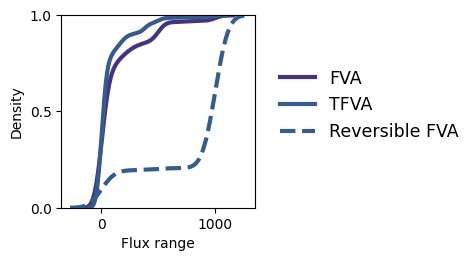

In [55]:
fig, ax = plt.subplots(figsize=(2.5,2.5))
scale_rcparams(fig)
sns.kdeplot(range_FVA, label='FVA',cumulative=True,ax=ax,linewidth=3)
sns.kdeplot(range_TFVA, label='TFVA', cumulative=True,ax=ax,linewidth=3)
sns.kdeplot(FVA_free_fluxes['range'],label='Reversible FVA',cumulative=True,ax=ax,linewidth=3,linestyle='--',color=sns.color_palette('viridis')[1])


ax.legend(frameon=False,bbox_to_anchor=(1.05, 0.8))
# ax.set_title("Value Distribution in DataFrame")
ax.set_ylim(0,1)
rescale_axlim(ax,how='y',nbins=3)
ax.set_xlabel('Flux range')
# ax.set_xscale('symlog',linthresh=1)

# plt.savefig(f'{OUTPUT_FOLDER}/R3_fluxranges_FVATFVA.png',dpi=300,bbox_inches='tight')
# plt.savefig(f'{OUTPUT_FOLDER}/R3_fluxranges_FVATFVA.svg',dpi=300,bbox_inches='tight')



[]

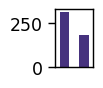

In [56]:
fig,ax=plt.subplots(figsize=(0.5,0.75))
ax.bar([0,0.4],[nlargeFVA,nlargeTFVA],width=0.2)
ax.set_xlim(-0.2,0.6)
ax.set_xticks([])

In [61]:
import json

In [ ]:
# ## save data for plotting 
# range_FVA.to_csv(f'{PLOTTING_DATA_FOLDER}/kde_fluxranges_range_FVA.csv')
# range_TFVA.to_csv(f'{PLOTTING_DATA_FOLDER}/kde_fluxranges_range_TFVA.csv')
# FVA_free_fluxes['range'].to_csv(f'{PLOTTING_DATA_FOLDER}/kde_fluxranges_range_FVA_free.csv')

# with open(f'{PLOTTING_DATA_FOLDER}/inset_plot_nlarge.json', 'w') as outfile:
#     json.dump({'nlargeFVA':nlargeFVA,'nlargeTFVA':nlargeTFVA}, outfile)


### b) TFBA glucose uptake rate scan then compare reaction directions with FBA gur-scan

In [ ]:
# add the TFBA variables to the model
tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = (3700/tmodel.T.m), error_type = 'covariance',qnorm=1,alpha=0.95)
tmodel.m.update()
tmodel.m.params.timelimit=60*5

GUR_range = np.linspace(-0, -20, 20)

thermo_flux.solver.gurobi.variable_scan(tmodel, GUR_range, var = tmodel.mvars['v'][0][tmodel.reactions.index(tmodel.reactions.get_by_id('EX_glc__D_e'))]) # here we get the index for the glucose uptake reaction and use this to index the v variable in the gurobi model
thermo_flux.solver.gurobi.model_start(tmodel,'fixed_dir_firstTFBA.sol',ignore_vars=['all'],fix_vars=['qm'],fix='bound') #fix the drG error term to that from the initial TFBA to speed up optimisations

tmodel.m.optimize()

fluxes_TFBA = thermo_flux.solver.gurobi.multi_scenario_sol(tmodel,var = 'v') 
fluxes_TFBA = pd.DataFrame(fluxes_TFBA[0].T, index = [rxn.id for rxn in tmodel.reactions])
fluxes_TFBA.columns=GUR_range


Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  300
NonConvex  2

Optimize a model with 14481 rows, 13060 columns and 341346 nonzeros (Max)
Model fingerprint: 0x4c8c92fa
Model has 2 linear objective coefficients
Model has 166 quadratic constraints
Model has 1 simple general constraint
  1 NORM
Variable types: 11466 continuous, 1594 integer (1594 binary)
Coefficient statistics:
  Matrix range     [6e-06, 1e+06]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-06, 1e+06]
  RHS range        [7e-15, 1e+06]

Solving a multi-scenario model with 20 scenarios...

Presolve removed 9671 ro

In [ ]:
fluxes_FBA=pd.DataFrame(index=[rxn.id for rxn in tmodel.reactions])
for gur in GUR_range:
    tmodel.reactions.get_by_id('EX_glc__D_e').bounds = gur,gur
    sol=tmodel.optimize()
    fluxes_FBA[gur]=sol.to_frame()['fluxes']

In [ ]:
def row_sign(row):
    return row.apply(lambda x:1 if x>0 else (-1 if x<0 else 0))
df_vdir_FBA=fluxes_FBA.apply(row_sign)
df_vdir_TFBA=fluxes_TFBA.apply(row_sign)


In [ ]:
matches_per_row = (df_vdir_FBA == df_vdir_TFBA).sum(axis=1)
mismatches_per_row = (df_vdir_FBA != df_vdir_TFBA).sum(axis=1)

print(mismatches_per_row.value_counts())
print(df_vdir_FBA.shape[0]-1344) 
df_vdir_FBA.shape[0]

0     1359
1       28
14      21
11      18
8       17
19      17
2       16
4       13
16      13
3       13
5       12
9       11
15       9
10       8
7        8
13       8
17       7
6        7
18       5
20       4
12       1
Name: count, dtype: int64
251


1595

### b) adding TFBA change direction compared to FBA for 15% of all reactions, what are these reactions ? -> pie chart with pathways

In [ ]:
diff_rxn=mismatches_per_row[mismatches_per_row>0].index
df_diff_rxn=pd.DataFrame(index=diff_rxn)
for rxnid in diff_rxn:
    try:
        df_diff_rxn.loc[rxnid,'Subsystem']=model.reactions.get_by_id(rxnid).subsystem
    except:
        pass

In [ ]:
counts=df_diff_rxn.value_counts()
threshold = 4.5
counts_agg = counts.copy()


# Convert to percentages
counts_agg = counts_agg / counts_agg.sum() * 100
# Group low-frequency categories into "Other"
low_freq = counts_agg[counts_agg < threshold]
counts_agg = counts_agg[counts_agg >= threshold]
counts_agg["Other"] = low_freq.sum()

In [ ]:
counts_agg

Subsystem                   
S_Transport__Mitochondrial      16.228070
S_Nucleotide_Salvage_Pathway    10.087719
S_Oxidative_Phosphorylation      6.578947
S_Fatty_Acid__Biosynthesis       5.263158
Other                           61.842105
Name: count, dtype: float64

In [ ]:
fig, ax = plt.subplots(figsize=(2.5,2.5))
scale_rcparams(fig)

pieplot = counts_agg.copy()
# Move first element to position 4
pieplot = pd.concat([pieplot.iloc[1:5][::-1], pieplot.iloc[[0]], pieplot.iloc[5:]])
c=sns.color_palette('viridis',n_colors=8)
colors = [c[4]] + [c[3]] +[c[2]]  + [c[1]]+ [c[0]] + [c[-3]] + [c[-1]]
ax.pie(
    pieplot ,explode=[0,0.0,0.0,0,0.05,0],
    wedgeprops={"linewidth": 2, "edgecolor": "white"},startangle=18,     
    labels = pieplot.index,colors=colors,
    autopct='%1.0f%%',)

#save
# plt.savefig(f'{OUTPUT_FOLDER}/PIE_TFBAgdiss_FBA_directionnalitychanges.png',dpi=300)
# plt.savefig(f'{OUTPUT_FOLDER}/PIE_TFBAgdiss_FBA_directionnalitychanges.svg',dpi=300)

### d) compare TFBA gur-scan predictions with experimental data

In [ ]:
##reset model with only one scenario
tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = (3800/tmodel.T.m), error_type = 'covariance',qnorm=1,alpha=0.95)
thermo_flux.solver.gurobi.model_start(tmodel,'fixed_dir_firstTFBA.sol',ignore_vars=['all'],fix_vars=['qm'],fix='bound') #fix the drG error term to that from the initial TFBA to speed up optimisations

tmodel.m.update()
tmodel.m.params.timelimit=60*5

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 300


In [ ]:
# add the TFBA variables to the model
tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = (3700/tmodel.T.m), error_type = 'covariance',qnorm=1,alpha=0.95)
tmodel.m.update()
tmodel.m.params.timelimit=60*5

GUR_range = np.linspace(-0, -23, 50)

thermo_flux.solver.gurobi.variable_scan(tmodel, GUR_range, var = tmodel.mvars['v'][0][tmodel.reactions.index(tmodel.reactions.get_by_id('EX_glc__D_e'))]) # here we get the index for the glucose uptake reaction and use this to index the v variable in the gurobi model
thermo_flux.solver.gurobi.model_start(tmodel,'fixed_dir_firstTFBA.sol',ignore_vars=['all'],fix_vars=['qm'],fix='bound') #fix the drG error term to that from the initial TFBA to speed up optimisations

tmodel.m.optimize()

fluxes_gdiss = thermo_flux.solver.gurobi.multi_scenario_sol(tmodel,var = 'v') 
fluxes_gdiss= pd.DataFrame(fluxes_gdiss[0].T, index = [rxn.id for rxn in tmodel.reactions])

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 300
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 15734 rows, 13067 columns and 351222 nonzeros
Model fingerprint: 0x313fda83
Model has 166 quadratic constraints
Model has 1 general constraint
Variable types: 11472 continuous, 1595 integer (1595 binary)
Coefficient statistics:
  Matrix range     [6e-06, 1e+06]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-06, 1e+06]
  RHS range        [7e-15, 1e+06]

Solving a multi-scenario model with 50 scenarios...

Presolve removed 10922 rows and 8665 columns
Presolve time: 0.10s
Presolved: 5143 rows, 4452 columns, 15703 nonzeros
Presolved model has 82 b

In [ ]:
#plot biomass yield for stoichiometric model with balanced reactions and pH specified
df_data2 = pd.read_csv('plotting_Yeast_ALL_experimental_data.csv',index_col=0)
df_data2['regression'].fillna('Not fitted',inplace=True)
df_data2['regression'].replace('yes', 'Fitted', inplace=True)
df_data2.rename(columns={'regression':'Exp. data'}, inplace=True)
#rename index in Condition
df_data2.index.rename('Condition', inplace=True)




In [ ]:
## first gur scan plot
GUR_plot_range=[-x for x in GUR_range]
#plot biomass vs GUR in a scatter plot

sns.scatterplot(x=GUR_plot_range,y=fluxes_gdiss.loc['biomass_EX'],color='b',label='TFBA')
# sns.scatterplot(x=GUR_plot_range,y=tbiomass_flux,color='b',label='FBA and balanced')
# sns.scatterplot(x=GUR_plot_range,y=biomass_flux,color='g',label='FBA')
sns.scatterplot(x=df_data2['glc-D_EX'], y=df_data2['biomass_EX'], color=['red'],label='Experimental data')
plt.xlabel('Glucose uptake rate (mmol/(gDW.h))',fontsize=14)
plt.ylabel('Biomass production rate (mmol/(gDW.h))',fontsize=14)

# plt.savefig('Figures/growth_all_TFBA_gdissconstraint.png',dpi=300)

instead of a glc uptake rate scan, we take values of glucose uptake in physiology data  and compare other predicted ex. fluxes

In [ ]:
tmodel.m = None #reset the gurobi model object in case you're re-running this cell 

tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = (3700/tmodel.T.m), error_type = 'covariance',qnorm=1,alpha=0.95)
thermo_flux.solver.gurobi.model_start(tmodel,'fixed_dir_firstTFBA.sol',ignore_vars=['all'],fix_vars=['qm'],fix='bound') #fix the drG error term to that from the initial TFBA to speed up optimisations

tmodel.m.update()
tmodel.m.params.timelimit=60*20

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 1200


In [ ]:
ex_data=['biomass_EX', 'EX_ac_e', 'EX_glyc_e', 'co2_EX', 'etoh_EX', 'o2_EX']
ex_flux_df=pd.DataFrame(index=ex_data)
j=0
glc_flux=[]
for i,row in df_data2.iterrows():
    try :
        bio=row['glc-D_EX']
        tmodel.mvars['v'][0][tmodel.reactions.index('EX_glc__D_e')].lb=-bio
        tmodel.mvars['v'][0][tmodel.reactions.index('EX_glc__D_e')].ub=-bio
        tmodel.m.optimize()
        ex_flux_df[j]=tmodel.solution().loc[ex_flux_df.index,'v']
        glc_flux.append(tmodel.solution().loc['EX_glc__D_e','v'])
    except Exception as e:
        print(e)
        pass
    j+=1


Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 15734 rows, 13067 columns and 351222 nonzeros
Model fingerprint: 0xf96dc78b
Model has 166 quadratic constraints
Model has 1 general constraint
Variable types: 11472 continuous, 1595 integer (1595 binary)
Coefficient statistics:
  Matrix range     [6e-06, 1e+06]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-06, 1e+06]
  RHS range        [7e-15, 1e+06]
Presolve removed 10086 rows and 8338 columns
Presolve time: 0.13s
Presolved: 6248 rows, 4729 columns, 19046 nonzeros
Presolved model has 150 bilinear constraint(s)

Solving non-convex MIQCP

Variable types: 3760 continuous, 969 integer (969 binary)

Root relaxation: objective 3.868053e+01, 6829 iterati

In [ ]:
ex_flux_df.loc['glc-D_EX']=glc_flux


(<matplotlib.patches.Rectangle at 0x78c36583cf70>,
 (<matplotlib.patches.ConnectionPatch at 0x78c357ba9870>,
  <matplotlib.patches.ConnectionPatch at 0x78c3585a7160>))

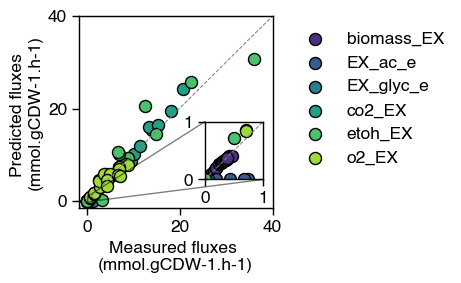

In [ ]:
## scatter plot conditions vs fluxes

fig, ax = plt.subplots(figsize=(2.5,2.5))
axin=ax.inset_axes([0.65,0.15,0.3,0.3])

scale_rcparams(fig)
mapping_rxnnames={'biomass_EX':'biomass_EX','EX_ac_e':'ac_EX','EX_glyc_e':'glyc_EX','co2_EX':'co2tot_EX','etoh_EX':'etoh_EX','o2_EX':'o2_EX'}
vircols=sns.color_palette('viridis',n_colors=len(ex_data))
for rxn,color in zip(ex_data,vircols):
    x=df_data2[mapping_rxnnames[rxn]]
    y=ex_flux_df.loc[rxn] if rxn not in ['o2_EX'] else -ex_flux_df.loc[rxn]
    ax.scatter(x,y,s=75,edgecolor='black',color=color,label=rxn)

    ## add an inset ax with zoom bottom right
    axin.scatter(x,y,s=75,edgecolor='black',color=color)

#fformating
ax.set_xlabel('Measured fluxes \n(mmol.gCDW-1.h-1)')
ax.set_ylabel('Predicted fluxes \n(mmol.gCDW-1.h-1)')
#diag
ax.plot([0,1],[0,1],transform=ax.transAxes,color='grey',linestyle='--')
ax.legend(frameon=False,bbox_to_anchor=(1.05, 1))
ax.set_xticks([0,20,40])
ax.set_yticks([0,20,40])


axin.plot([0,1],[0,1],transform=axin.transAxes,color='grey',linestyle='--')
axin.set_xlim(0,1)
axin.set_ylim(0,1)
axin.set_xticks([0,1])
axin.set_yticks([0,1])
axin.set_xlabel('')
axin.set_ylabel('')
ax.indicate_inset_zoom(axin,edgecolor='black')

#save 
# plt.savefig(f'{OUTPUT_FOLDER}/scatter_predictions_allglucoseconds.png',dpi=300)
# plt.savefig(f'{OUTPUT_FOLDER}/scatter_predictions_allglucoseconds.svg',dpi=300)

(<matplotlib.patches.Rectangle at 0x78c3836a6230>,
 (<matplotlib.patches.ConnectionPatch at 0x78c35ac38760>,
  <matplotlib.patches.ConnectionPatch at 0x78c35ac39210>))

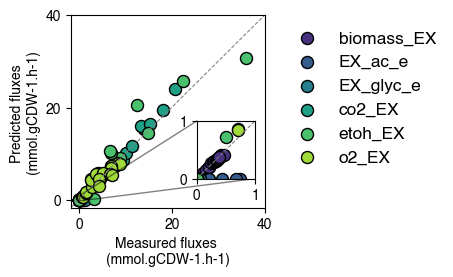

In [ ]:
## scatter plot conditions vs fluxes

fig, ax = plt.subplots(figsize=(2.5,2.5))
axin=ax.inset_axes([0.65,0.15,0.3,0.3])

scale_rcparams(fig)
mapping_rxnnames={'biomass_EX':'biomass_EX','EX_ac_e':'ac_EX','EX_glyc_e':'glyc_EX','co2_EX':'co2tot_EX','etoh_EX':'etoh_EX','o2_EX':'o2_EX'}
vircols=sns.color_palette('viridis',n_colors=len(ex_data))
for rxn,color in zip(ex_data,vircols):
    x=df_data2[mapping_rxnnames[rxn]]
    y=ex_flux_df.loc[rxn] if rxn not in ['o2_EX'] else -ex_flux_df.loc[rxn]
    ax.scatter(x,y,s=75,edgecolor='black',color=color,label=rxn)

    ## add an inset ax with zoom bottom right
    axin.scatter(x,y,s=75,edgecolor='black',color=color)

#fformating
ax.set_xlabel('Measured fluxes \n(mmol.gCDW-1.h-1)')
ax.set_ylabel('Predicted fluxes \n(mmol.gCDW-1.h-1)')
#diag
ax.plot([0,1],[0,1],transform=ax.transAxes,color='grey',linestyle='--')
ax.legend(frameon=False,bbox_to_anchor=(1.05, 1))
ax.set_xticks([0,20,40])
ax.set_yticks([0,20,40])


axin.plot([0,1],[0,1],transform=axin.transAxes,color='grey',linestyle='--')
axin.set_xlim(0,1)
axin.set_ylim(0,1)
axin.set_xticks([0,1])
axin.set_yticks([0,1])
axin.set_xlabel('')
axin.set_ylabel('')
ax.indicate_inset_zoom(axin,edgecolor='black')

#save 
# plt.savefig(f'{OUTPUT_FOLDER}/scatter_predictions_allglucoseconds.png',dpi=300)
# plt.savefig(f'{OUTPUT_FOLDER}/scatter_predictions_allglucoseconds.svg',dpi=300)

In [42]:
ax

NameError: name 'ax' is not defined